# P4-01 — Users as devices: what one user's history looks like

## Goal

The federated deployment study simulates every user as **one device**: the device keeps its own
browsing history, trains on it locally, and never shares it. Before any model is involved, this
notebook checks that the picture is sensible and explains one design choice, namely why the study
keeps **users with 5 to 100 training examples**.

- how much history a user has (events per user, and how the users split into activity bands)
- what a visit looks like (session length)
- how varied one user's browsing is (distinct products and categories)
- how often a user goes back to something they already viewed
- where the chronological split boundaries fall

## What this notebook does not do

It measures the **training period only**, that is everything before 16 November 2019. The validation
week (16-22 November) and the test week (23-29 November) are not loaded, counted or plotted here.
The timeline at the end draws their boundary lines and nothing else.

No model is trained and nothing is tuned. Every number below is a description of the training data.

## 1. Setup and data

The data is the frozen REES46 copy (October and November 2019 store events, already cleaned and
turned into next-product decisions). It is not in git; see `docs/data-access.md` for how the team
shares data. Set `REES46_FROZEN_DIR` to the folder if it is not found automatically.

Two tables from it are used, both read **one user bucket at a time** and only the columns needed:

| Table | What it gives us |
|---|---|
| decision index, `TRAIN` partition | one row per training decision and whether it is a usable training example |
| model-ready features | the product and category of each viewed item, its time and its session |

Nothing is sampled: the 64 buckets are read in turn and reduced to per-user numbers, so memory
stays small.

In [1]:
"""P4-01: describe the training period from the point of view of a single user (one device)."""

import json
import os
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})
pd.set_option("display.width", 200)

BLUE, GREY, ORANGE = "#2b6cb0", "#b9bec7", "#d9822b"

# Chronological split (UTC, half-open). Only TRAIN_END is used to filter data.
TRAIN_START = pd.Timestamp("2019-10-01")
TRAIN_END = pd.Timestamp("2019-11-16")        # training is everything before this
VALIDATION_END = pd.Timestamp("2019-11-23")   # boundary line only
TEST_END = pd.Timestamp("2019-11-30")         # boundary line only


def find_frozen_dataset():
    """Locate the frozen dataset folder without hard-coding a machine-specific path."""
    override = os.environ.get("REES46_FROZEN_DIR")
    if override:
        return Path(override)
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        for relative in ("data/rees46_nextitem_v1", "rees46_nextitem_v1", "eda/rees46_nextitem_v1"):
            candidate = base / relative
            if (candidate / "VERSION.json").is_file():
                return candidate
    raise FileNotFoundError("Frozen dataset not found; set REES46_FROZEN_DIR.")


DATA = find_frozen_dataset()
version = json.loads((DATA / "VERSION.json").read_text(encoding="utf-8"))
INDEX_DIR = DATA / "decisions_index" / "split=TRAIN"
FEATURE_DIR = DATA / "model_ready"
BUCKETS = sorted(int(p.name.split("=")[1]) for p in INDEX_DIR.iterdir())

print("Dataset      :", version["data_version"], "| hash", version["version_hash"][:8] + "...")
print("User buckets :", len(BUCKETS))
print("Training     :", TRAIN_START.date(), "to", (TRAIN_END - pd.Timedelta(days=1)).date())

Dataset      : rees46_nextitem_v1 | hash 860e5a1c...
User buckets : 64
Training     : 2019-10-01 to 2019-11-15


## 2. Training examples per user

A **training example** is a training-period decision with an observed next product that the model is
allowed to learn from. This is the study's own definition, so "5 to 100 examples" below means exactly
what it means in the experiments. A user can have many more views than examples, because the last view
of a session has nothing after it to predict.

We read the training partition of the decision index and count, for every user, the examples and all
decisions. The timestamp assertion is a guard: nothing at or after 16 November may appear.

In [2]:
t0 = time.time()
user_parts, daily_parts = [], []

for bucket in BUCKETS:
    path = next((INDEX_DIR / f"user_bucket={bucket}").glob("*.parquet"))
    d = pq.read_table(
        path,
        columns=["user_id", "decision_ts", "target_ts", "target_class", "loss_mask"],
        partitioning=None,
    ).to_pandas()
    assert d["decision_ts"].max() < TRAIN_END, "a row from the validation period slipped in"

    d["uid"] = d["user_id"].astype("int64")
    d["usable"] = d["loss_mask"] & (d["target_class"] >= 0) & (d["target_ts"] < TRAIN_END)

    per_user = d.groupby("uid").agg(decisions=("usable", "size"), examples=("usable", "sum"))
    user_parts.append(per_user)
    daily_parts.append(d.loc[d["usable"], "decision_ts"].dt.floor("D").value_counts())

users = pd.concat(user_parts)
assert users.index.is_unique, "a user appears in two buckets"
users["examples"] = users["examples"].astype("int64")
daily_examples = pd.concat(daily_parts).groupby(level=0).sum().sort_index()
del user_parts, daily_parts

print(f"Users with at least one training decision : {len(users):,}")
print(f"Training decisions                        : {int(users['decisions'].sum()):,}")
print(f"Usable training examples                  : {int(users['examples'].sum()):,}")
print(f"Read time                                 : {time.time() - t0:.0f} s")

Users with at least one training decision : 4,204,379
Training decisions                        : 52,760,314
Usable training examples                  : 40,180,608
Read time                                 : 11 s


## 3. Events per user

Activity is heavily skewed, so the histogram uses log-spaced bins and a log count axis. The shaded
region is the 5-100 range the study keeps. Users with no usable example (zero) cannot appear on a log
axis; they are counted in the table further down.

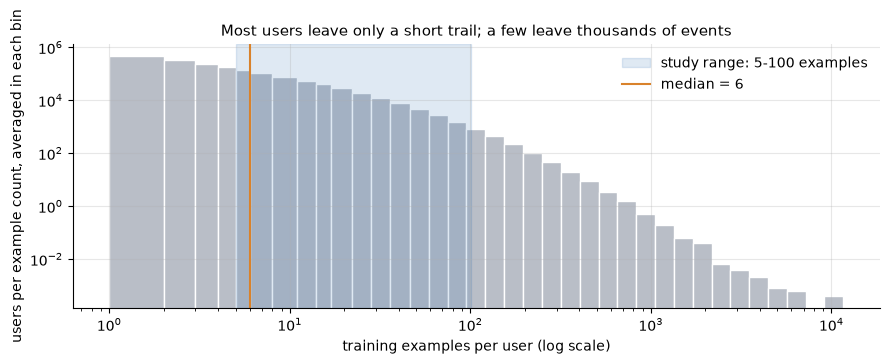

Examples per user (users with at least one example)
count    2694998.0
mean          14.9
std           33.2
min            1.0
25%            2.0
50%            6.0
75%           15.0
90%           35.0
99%          138.0
max        11628.0


In [3]:
n = users["examples"]
positive = n[n > 0]

# Whole-number bins that widen with size; each bar is divided by its width so heights are comparable.
edges = np.unique(np.floor(np.logspace(0, np.log10(positive.max() + 1), 40)).astype(int))
counts, _ = np.histogram(positive, bins=edges)
per_value = counts / np.diff(edges)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(edges[:-1], per_value, width=np.diff(edges), align="edge", color=GREY, edgecolor="white")
ax.axvspan(5, 101, color=BLUE, alpha=0.15, label="study range: 5-100 examples")
ax.axvline(np.median(positive), color=ORANGE, lw=1.5, label=f"median = {np.median(positive):.0f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training examples per user (log scale)")
ax.set_ylabel("users per example count, averaged in each bin")
ax.set_title("Most users leave only a short trail; a few leave thousands of events")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Examples per user (users with at least one example)")
print(positive.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(1).to_string())

## 4. Activity bands: share of users and share of events

Grouping users into bands shows who carries the data. Blue bands are the study range. The "0" band
holds users who were seen in the training period but have no usable example, for instance because
their only view has no later product to predict.

          users  examples  share_of_users_%  share_of_examples_%
band                                                            
0       1509381         0             35.90                 0.00
1-4     1197003   2503629             28.47                 6.23
5-10     594975   4199017             14.15                10.45
11-30    578987  10380120             13.77                25.83
31-100   273024  14044249              6.49                34.95
101+      51009   9053593              1.21                22.53


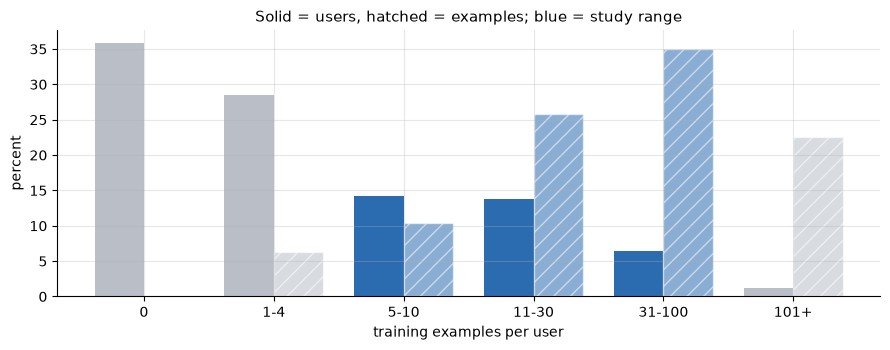


Study range (5-100): 1,446,986 users = 34.4% of all users (53.7% of users with at least one example), holding 71.2% of training examples
Above 100          : 51,009 users = 1.2% of users, holding 22.5% of training examples
Zero examples      : 1,509,381 users; 81% of them have a single training decision


In [4]:
EDGES = [-1, 0, 4, 10, 30, 100, np.inf]
LABELS = ["0", "1-4", "5-10", "11-30", "31-100", "101+"]
STUDY_BANDS = {"5-10", "11-30", "31-100"}
users["band"] = pd.cut(users["examples"], bins=EDGES, labels=LABELS)
users["study"] = users["examples"].between(5, 100)

bands = users.groupby("band", observed=True).agg(users=("examples", "size"), examples=("examples", "sum"))
bands["share_of_users_%"] = (100 * bands["users"] / bands["users"].sum()).round(2)
bands["share_of_examples_%"] = (100 * bands["examples"] / bands["examples"].sum()).round(2)
print(bands.to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(LABELS))
w = 0.38
ax.bar(x - w / 2, bands["share_of_users_%"], w, label="share of users",
       color=[BLUE if b in STUDY_BANDS else GREY for b in LABELS])
ax.bar(x + w / 2, bands["share_of_examples_%"], w, label="share of examples",
       color=[BLUE if b in STUDY_BANDS else GREY for b in LABELS], alpha=0.55, hatch="//",
       edgecolor="white")
ax.set_xticks(x, LABELS)
ax.set_xlabel("training examples per user")
ax.set_ylabel("percent")
ax.set_title("Solid = users, hatched = examples; blue = study range")
plt.tight_layout()
plt.show()

study = users[users["study"]]
print()
with_examples = (users["examples"] > 0).sum()
print(f"Study range (5-100): {len(study):,} users = {100 * len(study) / len(users):.1f}% of all users "
      f"({100 * len(study) / with_examples:.1f}% of users with at least one example), "
      f"holding {100 * study['examples'].sum() / users['examples'].sum():.1f}% of training examples")
heavy = users[users["examples"] > 100]
print(f"Above 100          : {len(heavy):,} users = {100 * len(heavy) / len(users):.1f}% of users, "
      f"holding {100 * heavy['examples'].sum() / users['examples'].sum():.1f}% of training examples")
zero = users[users["examples"] == 0]
print(f"Zero examples      : {len(zero):,} users; {100 * (zero['decisions'] == 1).mean():.0f}% of them have a "
      f"single training decision")

### Why 5 to 100

- **At least 5.** A device with one to four examples has almost nothing to learn from locally, and a
  per-user score computed on such a short history is mostly noise. The study reports its metric
  per user, so these users would add variance rather than information.
- **At most 100.** The users above 100 are a small minority, yet they hold a large share of all
  examples. On a device they would also train for many more steps than everyone else. Capping at 100
  keeps every simulated device comparable in size and stops a few heavy users from dominating the
  average.

Both thresholds are a design choice, not something the data dictates. What the data does show is how
much they keep: the study range covers a large part of the users, and the rest is a tail at each end.

## 5. Why one user can be one device

A device is a good stand-in for a user if three things hold in the data: the same user keeps coming
back (so a history builds up in one place), that history is small enough to live on the device, and
users differ enough that a personal model has something to learn. This section covers the first two;
sections 7 and 8 cover the third. All figures are for the study range.

Visit continuity needs when each user was first and last seen, how many sessions they had and on
how many different days. A **session** is a run of views with no gap above one hour.

In [5]:
t0 = time.time()
ts_filter = pa.scalar(TRAIN_END.to_pydatetime(), pa.timestamp("us"))
FEATURE_COLUMNS = ["user_id", "decision_id", "block_ts", "product_id", "session_index", "category_idx", "split"]

user_stats, session_parts = [], []

for bucket in BUCKETS:
    t = pq.read_table(
        FEATURE_DIR / f"user_bucket={bucket}" / "features.parquet",
        columns=FEATURE_COLUMNS,
        filters=(pc.field("split") == "TRAIN") & (pc.field("block_ts") < ts_filter),
        partitioning=None,
    ).to_pandas()
    assert t["block_ts"].max() < TRAIN_END

    t["uid"] = t["user_id"].astype("int64")
    t["pid"] = t["product_id"].astype("int64")
    t = t.sort_values(["uid", "block_ts", "decision_id"], kind="stable")
    t["repeat"] = t.duplicated(["uid", "pid"])          # product already viewed earlier by this user
    t["day"] = t["block_ts"].dt.floor("D")

    g = t.groupby("uid")
    s = pd.DataFrame({
        "views": g.size(),
        "repeat_views": g["repeat"].sum(),
        "sessions": g["session_index"].nunique(),
        "first_seen": g["block_ts"].min(),
        "last_seen": g["block_ts"].max(),
    })
    s["distinct_products"] = s["views"] - s["repeat_views"]
    s["active_days"] = t.drop_duplicates(["uid", "day"]).groupby("uid").size()

    known = t[t["category_idx"] >= 3]                    # 1 = missing, 2 = rare/unseen category
    per_cat = known.groupby(["uid", "category_idx"]).size()
    by_user = per_cat.groupby(level=0)
    s["distinct_categories"] = by_user.size()
    s["top_category_share"] = by_user.max() / by_user.sum()
    user_stats.append(s)

    sess = t.groupby(["uid", "session_index"]).agg(views=("pid", "size"),
                                                  start=("block_ts", "min"), end=("block_ts", "max"))
    session_parts.append(pd.DataFrame({
        "uid": sess.index.get_level_values(0).to_numpy(),
        "views": sess["views"].to_numpy(np.int32),
        "minutes": ((sess["end"] - sess["start"]).dt.total_seconds() / 60).to_numpy(np.float32),
    }))

stats = pd.concat(user_stats)
sessions = pd.concat(session_parts, ignore_index=True)
del user_stats, session_parts

assert stats.index.is_unique and set(stats.index) == set(users.index), "feature and index tables disagree"
stats["distinct_categories"] = stats["distinct_categories"].fillna(0)
users = users.join(stats)
sessions["study"] = sessions["uid"].map(users["study"]).to_numpy()
study = users[users["study"]]
print(f"Users: {len(users):,} | sessions: {len(sessions):,} | read time: {time.time() - t0:.0f} s")

Users: 4,204,379 | sessions: 12,515,840 | read time: 88 s


In [6]:
span_days = (study["last_seen"] - study["first_seen"]).dt.total_seconds() / 86400

continuity = pd.Series({
    "users in the study range": f"{len(study):,}",
    "median training examples": f"{study['examples'].median():.0f}",
    "median sessions": f"{study['sessions'].median():.0f}",
    "share with 2+ sessions": f"{100 * (study['sessions'] >= 2).mean():.1f}%",
    "median active days": f"{study['active_days'].median():.0f}",
    "share active on 2+ different days": f"{100 * (study['active_days'] >= 2).mean():.1f}%",
    "median days between first and last event": f"{span_days.median():.1f}",
})
print(continuity.to_string())

users in the study range                    1,446,986
median training examples                           13
median sessions                                     4
share with 2+ sessions                          83.3%
median active days                                  3
share active on 2+ different days               80.5%
median days between first and last event         16.1


## 6. Session length

How long is one visit? The left panel counts product views per session and the right panel shows how
long the session lasts in minutes. Single-view sessions have no duration and are left out of the
right panel. Back-to-back views of the same product are already merged into one in the cleaned data.

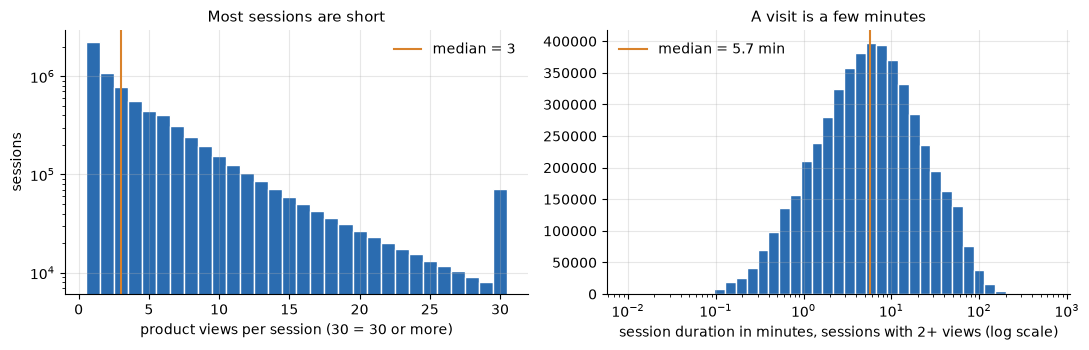

Study-range sessions: 7,239,450
Share with a single view: 30.9%


Views per session   - median 3, mean 5.0, 90th percentile 11
Minutes per session - median 5.7, 90th percentile 33.6 (sessions with 2+ views)


In [7]:
ss = sessions[sessions["study"]]
timed = ss[ss["views"] > 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

capped = ss["views"].clip(upper=30)
axes[0].hist(capped, bins=np.arange(0.5, 31.5, 1), color=BLUE, edgecolor="white")
axes[0].axvline(ss["views"].median(), color=ORANGE, lw=1.5, label=f"median = {ss['views'].median():.0f}")
axes[0].set_xlabel("product views per session (30 = 30 or more)")
axes[0].set_ylabel("sessions")
axes[0].set_yscale("log")
axes[0].set_title("Most sessions are short")
axes[0].legend(frameon=False)

bins = np.logspace(-2, np.log10(max(timed["minutes"].max(), 10)), 40)
axes[1].hist(timed["minutes"], bins=bins, color=BLUE, edgecolor="white")
axes[1].axvline(timed["minutes"].median(), color=ORANGE, lw=1.5,
                label=f"median = {timed['minutes'].median():.1f} min")
axes[1].set_xscale("log")
axes[1].set_xlabel("session duration in minutes, sessions with 2+ views (log scale)")
axes[1].set_title("A visit is a few minutes")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Study-range sessions: {len(ss):,}")
print(f"Share with a single view: {100 * (ss['views'] == 1).mean():.1f}%")
print(f"Views per session   - median {ss['views'].median():.0f}, mean {ss['views'].mean():.1f}, "
      f"90th percentile {ss['views'].quantile(0.9):.0f}")
print(f"Minutes per session - median {timed['minutes'].median():.1f}, "
      f"90th percentile {timed['minutes'].quantile(0.9):.1f} (sessions with 2+ views)")

## 7. How varied is one user's browsing?

For each user in the study range: how many **different products** and how many **different categories**
they viewed in the training period. A category is counted only when it is known; the small share of
views with a missing or very rare category is left out of the category count and the top-category
share.

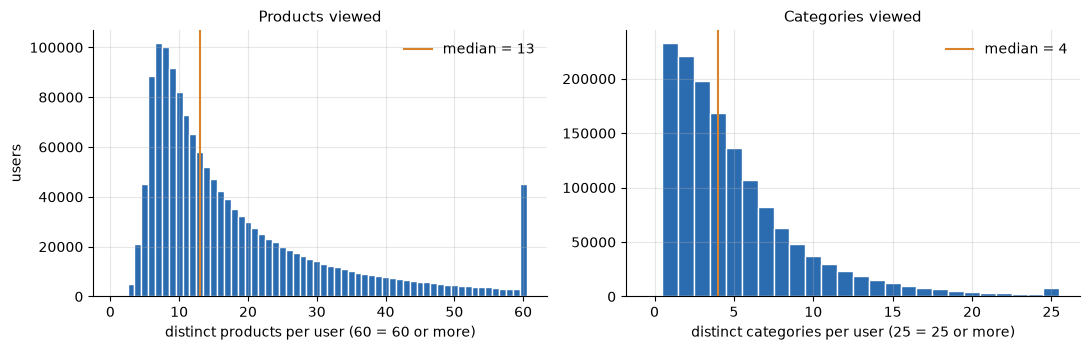

Distinct products   - median 13, 90th percentile 39
Distinct categories - median 4, 90th percentile 11
Share of a user's views in their single most-viewed category: median 60%
Users whose views fall in at most 3 categories: 45.1%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

cap = 60
axes[0].hist(study["distinct_products"].clip(upper=cap), bins=np.arange(0.5, cap + 1.5, 1),
             color=BLUE, edgecolor="white")
axes[0].axvline(study["distinct_products"].median(), color=ORANGE, lw=1.5,
                label=f"median = {study['distinct_products'].median():.0f}")
axes[0].set_xlabel(f"distinct products per user ({cap} = {cap} or more)")
axes[0].set_ylabel("users")
axes[0].set_title("Products viewed")
axes[0].legend(frameon=False)

cats = study["distinct_categories"].clip(upper=25)
axes[1].hist(cats, bins=np.arange(-0.5, 26.5, 1), color=BLUE, edgecolor="white")
axes[1].axvline(study["distinct_categories"].median(), color=ORANGE, lw=1.5,
                label=f"median = {study['distinct_categories'].median():.0f}")
axes[1].set_xlabel("distinct categories per user (25 = 25 or more)")
axes[1].set_title("Categories viewed")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

top = study["top_category_share"].dropna()
print(f"Distinct products   - median {study['distinct_products'].median():.0f}, "
      f"90th percentile {study['distinct_products'].quantile(0.9):.0f}")
print(f"Distinct categories - median {study['distinct_categories'].median():.0f}, "
      f"90th percentile {study['distinct_categories'].quantile(0.9):.0f}")
print(f"Share of a user's views in their single most-viewed category: median {100 * top.median():.0f}%")
print(f"Users whose views fall in at most 3 categories: "
      f"{100 * (study['distinct_categories'] <= 3).mean():.1f}%")

## 8. Repeat views versus new products

A view is a **repeat** when the same user has already viewed that product earlier in the training
period, and **new** when it is the first time. Repeats matter for a per-device model because the
device's own history is then a direct source of the answer.

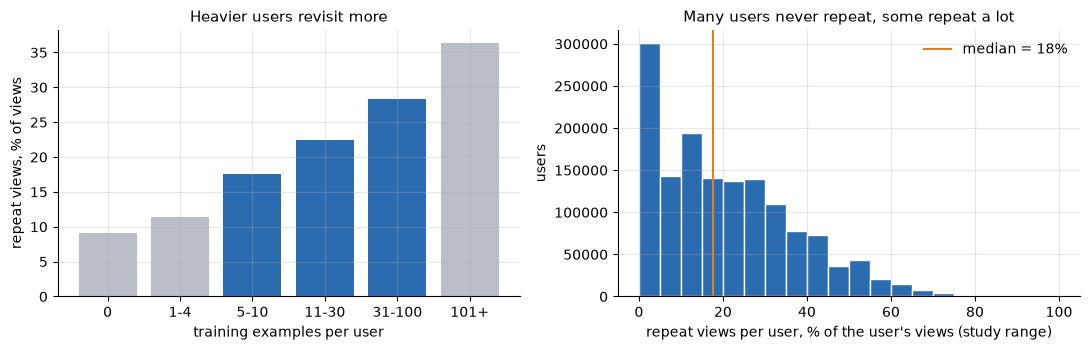

All users: 25.0% of views are repeats
Study range: 24.4% of views are repeats; 18.5% of users have none

Repeat share by band (%):
band
0          9.1
1-4       11.4
5-10      17.5
11-30     22.5
31-100    28.4
101+      36.4


In [9]:
by_band = users.groupby("band", observed=True)[["repeat_views", "views"]].sum()
repeat_share = 100 * by_band["repeat_views"] / by_band["views"]

user_repeat = 100 * study["repeat_views"] / study["views"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(repeat_share.index.astype(str), repeat_share.values,
            color=[BLUE if b in STUDY_BANDS else GREY for b in repeat_share.index.astype(str)])
axes[0].set_xlabel("training examples per user")
axes[0].set_ylabel("repeat views, % of views")
axes[0].set_title("Heavier users revisit more")

axes[1].hist(user_repeat, bins=np.linspace(0, 100, 21), color=BLUE, edgecolor="white")
axes[1].axvline(user_repeat.median(), color=ORANGE, lw=1.5, label=f"median = {user_repeat.median():.0f}%")
axes[1].set_xlabel("repeat views per user, % of the user's views (study range)")
axes[1].set_ylabel("users")
axes[1].set_title("Many users never repeat, some repeat a lot")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"All users: {100 * users['repeat_views'].sum() / users['views'].sum():.1f}% of views are repeats")
print(f"Study range: {100 * study['repeat_views'].sum() / study['views'].sum():.1f}% of views are repeats; "
      f"{100 * (study['repeat_views'] == 0).mean():.1f}% of users have none")
print()
print("Repeat share by band (%):")
print(repeat_share.round(1).to_string())

## 9. The chronological split

The study never shuffles time. It trains on the past and evaluates on later weeks, as a deployed
recommender would experience them. The plot shows the number of training examples per day and the
split boundaries. The validation and test weeks are **drawn as empty regions**: this notebook never
opens that data.

One thing stands out: the last two training days are far busier than the rest, and 15 November alone
has more than four times the median day. That is how the data looks, and it means a good part of
every user's history sits close to the split boundary.

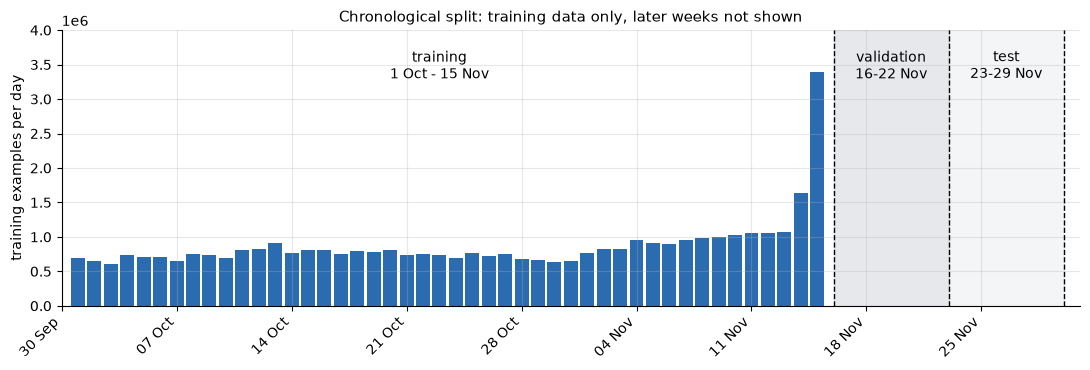

First training day : 2019-10-01
Last training day  : 2019-11-15
Days with examples : 46
Busiest day        : 2019-11-15 (3,392,253 examples)
Median day         : 767,308 examples
Last two days      : 12.5% of all training examples


In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8))

ax.bar(daily_examples.index, daily_examples.values, width=0.85, color=BLUE)
ax.axvspan(TRAIN_END, VALIDATION_END, color=GREY, alpha=0.35)
ax.axvspan(VALIDATION_END, TEST_END, color=GREY, alpha=0.15)
for boundary in (TRAIN_END, VALIDATION_END, TEST_END):
    ax.axvline(boundary, color="black", lw=1, ls="--")

ymax = daily_examples.max() * 1.18
ax.set_ylim(0, ymax)
ax.set_xlim(TRAIN_START - pd.Timedelta(days=1), TEST_END + pd.Timedelta(days=1))
ax.text(TRAIN_START + pd.Timedelta(days=22), ymax * 0.93, "training\n1 Oct - 15 Nov", ha="center", va="top")
ax.text(TRAIN_END + pd.Timedelta(days=3.5), ymax * 0.93, "validation\n16-22 Nov", ha="center", va="top")
ax.text(VALIDATION_END + pd.Timedelta(days=3.5), ymax * 0.93, "test\n23-29 Nov", ha="center", va="top")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("training examples per day")
ax.set_title("Chronological split: training data only, later weeks not shown")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"First training day : {daily_examples.index.min().date()}")
print(f"Last training day  : {daily_examples.index.max().date()}")
print(f"Days with examples : {len(daily_examples)}")
print(f"Busiest day        : {daily_examples.idxmax().date()} ({daily_examples.max():,} examples)")
last_two = daily_examples[daily_examples.index >= TRAIN_END - pd.Timedelta(days=2)].sum()
print(f"Median day         : {int(daily_examples.median()):,} examples")
print(f"Last two days      : {100 * last_two / daily_examples.sum():.1f}% of all training examples")

## 10. Summary

- **Scale.** 4.2 million users appear in the training period; 2.7 million of them have at least one
  usable training example. The middle user has 6 examples, and a small group leaves thousands.
- **The study range.** Users with 5 to 100 examples are 1.45 million users, about 54% of those with an
  example, and they carry 71% of all training examples. Users with 1 to 4 examples are numerous but
  hold little data; users above 100 are 1.2% of users but 22.5% of the examples.
- **A user behaves like a device.** In the study range 83% of users have two or more sessions and
  80% were active on two or more different days, with a median of about two weeks between first and
  last event. A history builds up in one place and stays small: a median of 13 examples.
- **A visit is short.** Median session: 3 product views; sessions with two or more views last about 6 minutes at the median. About 31% of sessions
  are a single view.
- **Users are personal.** The median user viewed 13 different products in 4 categories, and about 60%
  of their views fall in their single favourite category. About a quarter of all views are repeats of
  something the user has already seen.
- **The split is chronological.** Training ends on 15 November; validation (16-22 November) and test
  (23-29 November) come after it and are not used anywhere in this notebook.

**Caveat.** REES46 records a user id, not a device. A person browsing on two devices would show up as
two users, and a shared device as one. The data cannot tell us how often this happens, so "one user =
one device" is a modelling assumption that the study states openly rather than a fact we measured.